0:	learn: 1.0845877	total: 65.7ms	remaining: 1m 18s
200:	learn: 0.8865912	total: 1.66s	remaining: 8.27s
400:	learn: 0.8093958	total: 3.31s	remaining: 6.59s
600:	learn: 0.7397310	total: 5.08s	remaining: 5.06s
800:	learn: 0.6736164	total: 6.77s	remaining: 3.37s
1000:	learn: 0.6164018	total: 8.43s	remaining: 1.68s
1199:	learn: 0.5658124	total: 10.1s	remaining: 0us
Rows used: 7700 | Features: 11
Target classes: ['A', 'D', 'H']
Test log loss: 1.007977237557602


/cbica/home/dadashkj/.conda/envs/pushkar/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


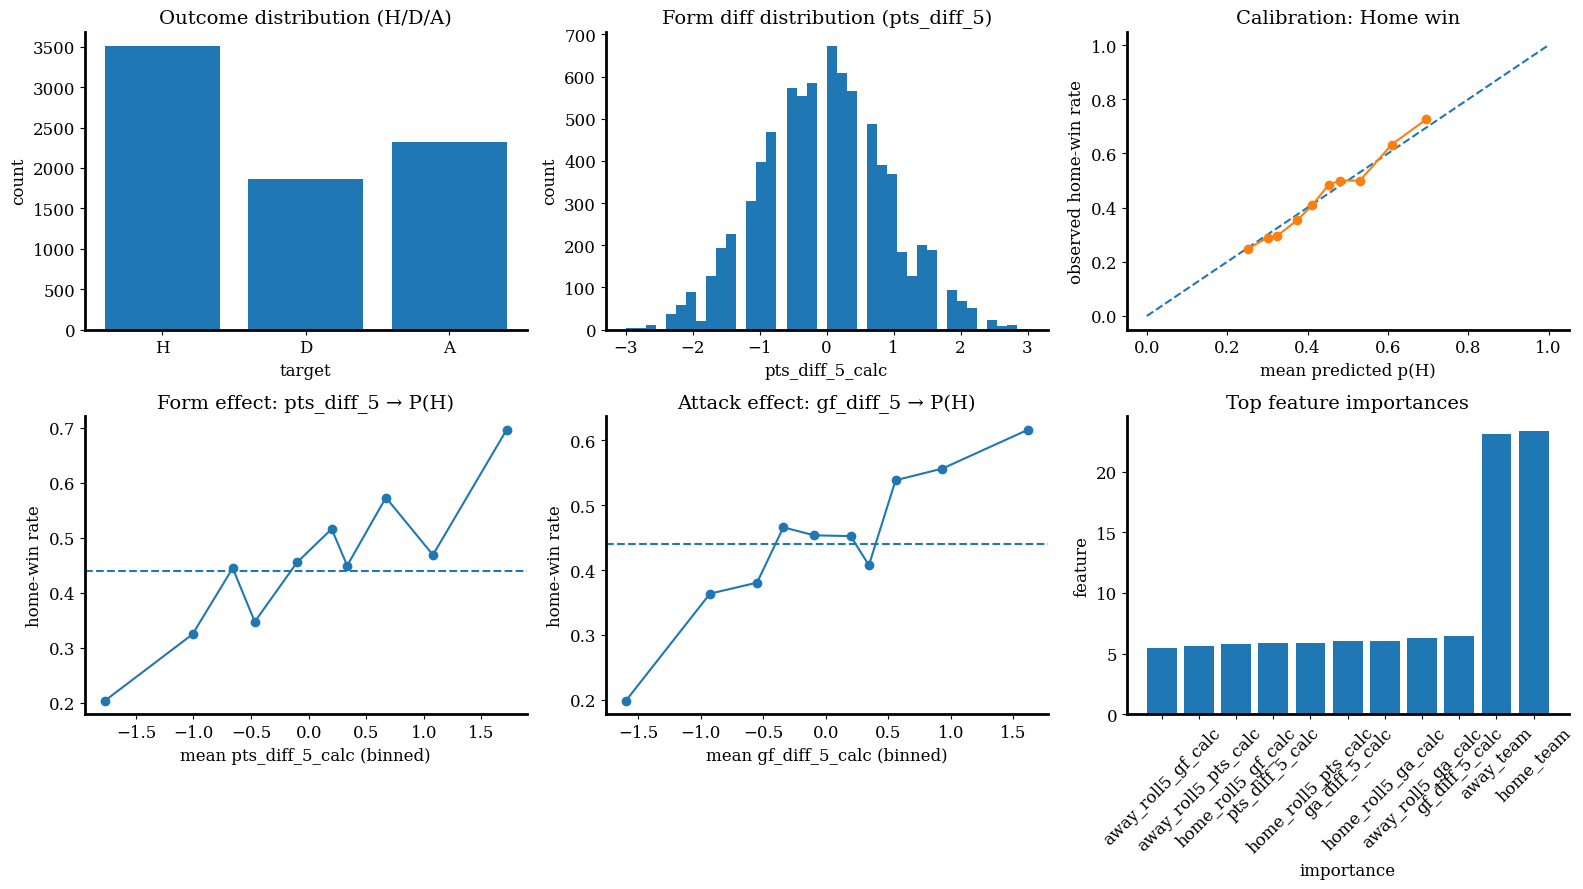


================= NEXT WEEK SUMMARY =================


,date,home_team,away_team,p_home,p_draw,p_away,pick,confidence
0,2026-02-28,Liverpool,West Ham,0.630782,0.203506,0.165712,home,0.630782
1,2026-02-28,Burnley,Brentford,0.486365,0.252777,0.260858,home,0.486365
2,2026-02-28,Leeds,Man City,0.305993,0.235244,0.458763,away,0.458763
3,2026-02-28,Wolves,Aston Villa,0.454986,0.236469,0.308544,home,0.454986
4,2026-02-28,Newcastle,Everton,0.334572,0.227839,0.437589,away,0.437589
5,2026-02-28,Bournemouth,Sunderland,0.430596,0.245130,0.324274,home,0.430596



2026-02-28 | Wolves vs Aston Villa
Suggestion: HOME  (confidence=0.455)


,Outcome,p_model
0,Home (H),0.454986
1,Draw (D),0.236469
2,Away (A),0.308544



2026-02-28 | Bournemouth vs Sunderland
Suggestion: HOME  (confidence=0.431)


...


2026-02-28 | Liverpool vs West Ham
Suggestion: HOME  (confidence=0.631)


,Outcome,p_model
0,Home (H),0.630782
1,Draw (D),0.203506
2,Away (A),0.165712



2026-02-28 | Leeds vs Man City
Suggestion: AWAY  (confidence=0.459)


,Outcome,p_model
0,Home (H),0.305993
1,Draw (D),0.235244
2,Away (A),0.458763



✅ Done.


In [1]:
# ============================================================
# EPL Next-Week Predictor (NO-ODDS) — SAFE VERSION
# Fixes: "columns overlap" by writing rolling features into *_calc columns
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import log_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from catboost import CatBoostClassifier

# -------------------- CONFIG --------------------
CSV_PATH    = "epl_master_train_full.csv"
MIN_DATE    = "2005-01-01"
NAN_THRESH  = 0.90
ROLL_N      = 5
RANDOM_SEED = 42

fixtures = [
    ("2026-02-28", "Wolves",       "Aston Villa"),
    ("2026-02-28", "Bournemouth",  "Sunderland"),
    ("2026-02-28", "Newcastle",    "Everton"),
    ("2026-02-28", "Burnley",      "Brentford"),
    ("2026-02-28", "Liverpool",    "West Ham"),
    ("2026-02-28", "Leeds",        "Man City"),
]
fixtures_df = pd.DataFrame(fixtures, columns=["date","home_team","away_team"])
fixtures_df["date"] = pd.to_datetime(fixtures_df["date"])

# -------------------- helper: team name cleaning --------------------
def clean_team_name(x: str) -> str:
    if pd.isna(x):
        return x
    s = str(x).strip()
    repl = {
        "Wolverhampton": "Wolves",
        "Manchester City": "Man City",
        "Manchester United": "Man United",
        "West Ham United": "West Ham",
        "Nott'm Forest": "Nottm Forest",
        "Nottingham Forest": "Nottm Forest",
        "Spurs": "Tottenham",
    }
    return repl.get(s, s)

# -------------------- load + cleanup --------------------
df0 = pd.read_csv(CSV_PATH, low_memory=False)
df0["date"] = pd.to_datetime(df0["date"], errors="coerce")

rename_map = {"HomeTeam": "home_team", "AwayTeam": "away_team", "FTHG": "home_goals", "FTAG": "away_goals", "FTR": "ft_result"}
for k,v in rename_map.items():
    if k in df0.columns and v not in df0.columns:
        df0 = df0.rename(columns={k:v})

df0 = df0.loc[:, df0.isna().mean() <= NAN_THRESH].copy()

need = ["date","home_team","away_team","home_goals","away_goals","target"]
missing = [c for c in need if c not in df0.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nFound: {list(df0.columns)[:30]}")

df0["home_team"] = df0["home_team"].map(clean_team_name)
df0["away_team"] = df0["away_team"].map(clean_team_name)

df0 = df0[df0["date"].notna() & (df0["date"] >= pd.to_datetime(MIN_DATE))].copy()
df0["target"] = df0["target"].astype(str).str.strip()
df0 = df0[df0["target"].isin(["H","D","A"])].copy()

df0["home_goals"] = pd.to_numeric(df0["home_goals"], errors="coerce")
df0["away_goals"] = pd.to_numeric(df0["away_goals"], errors="coerce")
df0 = df0[df0["home_goals"].notna() & df0["away_goals"].notna()].copy()

df0 = df0.sort_values("date").reset_index(drop=True)

# -------------------- build per-team rolling stats (fresh) --------------------
def result_points(hg, ag):
    if hg > ag:  return 3, 0
    if hg < ag:  return 0, 3
    return 1, 1

rows = []
for i, r in df0.iterrows():
    hg, ag = r["home_goals"], r["away_goals"]
    hp, ap = result_points(hg, ag)
    dt = r["date"]
    rows.append({"match_idx": i, "date": dt, "team": r["home_team"], "is_home": 1, "pts": hp, "gf": hg, "ga": ag})
    rows.append({"match_idx": i, "date": dt, "team": r["away_team"], "is_home": 0, "pts": ap, "gf": ag, "ga": hg})

long = pd.DataFrame(rows).sort_values(["team","date","match_idx"]).reset_index(drop=True)

for col in ["pts","gf","ga"]:
    long[f"roll{ROLL_N}_{col}"] = (
        long.groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(ROLL_N, min_periods=ROLL_N).mean())
    )

# write to unique *_calc names to avoid collisions with your dataset
home_feats = (
    long[long["is_home"] == 1]
    .set_index("match_idx")[[f"roll{ROLL_N}_pts", f"roll{ROLL_N}_gf", f"roll{ROLL_N}_ga"]]
    .rename(columns={
        f"roll{ROLL_N}_pts": f"home_roll{ROLL_N}_pts_calc",
        f"roll{ROLL_N}_gf":  f"home_roll{ROLL_N}_gf_calc",
        f"roll{ROLL_N}_ga":  f"home_roll{ROLL_N}_ga_calc",
    })
)

away_feats = (
    long[long["is_home"] == 0]
    .set_index("match_idx")[[f"roll{ROLL_N}_pts", f"roll{ROLL_N}_gf", f"roll{ROLL_N}_ga"]]
    .rename(columns={
        f"roll{ROLL_N}_pts": f"away_roll{ROLL_N}_pts_calc",
        f"roll{ROLL_N}_gf":  f"away_roll{ROLL_N}_gf_calc",
        f"roll{ROLL_N}_ga":  f"away_roll{ROLL_N}_ga_calc",
    })
)

df = df0.join(home_feats, how="left").join(away_feats, how="left")

df[f"pts_diff_{ROLL_N}_calc"] = df[f"home_roll{ROLL_N}_pts_calc"] - df[f"away_roll{ROLL_N}_pts_calc"]
df[f"gf_diff_{ROLL_N}_calc"]  = df[f"home_roll{ROLL_N}_gf_calc"]  - df[f"away_roll{ROLL_N}_gf_calc"]
df[f"ga_diff_{ROLL_N}_calc"]  = df[f"home_roll{ROLL_N}_ga_calc"]  - df[f"away_roll{ROLL_N}_ga_calc"]

feat_need = [
    f"home_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_pts_calc",
    f"home_roll{ROLL_N}_gf_calc",  f"away_roll{ROLL_N}_gf_calc",
    f"home_roll{ROLL_N}_ga_calc",  f"away_roll{ROLL_N}_ga_calc",
]
df = df[df[feat_need].notna().all(axis=1)].copy()
df = df.sort_values("date").reset_index(drop=True)

# -------------------- train matrices --------------------
cat_feats = ["home_team", "away_team"]
num_feats = [
    f"home_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_pts_calc", f"pts_diff_{ROLL_N}_calc",
    f"home_roll{ROLL_N}_gf_calc",  f"away_roll{ROLL_N}_gf_calc",  f"gf_diff_{ROLL_N}_calc",
    f"home_roll{ROLL_N}_ga_calc",  f"away_roll{ROLL_N}_ga_calc",  f"ga_diff_{ROLL_N}_calc",
]
feature_cols = cat_feats + num_feats

X = df[feature_cols].copy()
y = df["target"].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)

split_idx = int(len(df) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_enc[:split_idx], y_enc[split_idx:]

cat_idx = [X_train.columns.get_loc(c) for c in cat_feats]

model = CatBoostClassifier(
    loss_function="MultiClass",
    depth=6,
    learning_rate=0.08,
    iterations=1200,
    random_seed=RANDOM_SEED,
    verbose=200
)
model.fit(X_train, y_train, cat_features=cat_idx)

cal = CalibratedClassifierCV(model, method="isotonic", cv="prefit")
cal.fit(X_test, y_test)

probs_test = cal.predict_proba(X_test)
print("Rows used:", len(df), "| Features:", len(feature_cols))
print("Target classes:", list(le.classes_))
print("Test log loss:", log_loss(y_test, probs_test))

# -------------------- Nature-ish viz (2x3) --------------------
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 2.0,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

vc = df["target"].value_counts().reindex(["H","D","A"])
axes[0].bar(vc.index, vc.values)
axes[0].set_title("Outcome distribution (H/D/A)")
axes[0].set_xlabel("target")
axes[0].set_ylabel("count")

axes[1].hist(df[f"pts_diff_{ROLL_N}_calc"].dropna(), bins=40)
axes[1].set_title(f"Form diff distribution (pts_diff_{ROLL_N})")
axes[1].set_xlabel(f"pts_diff_{ROLL_N}_calc")
axes[1].set_ylabel("count")

class_names = list(le.classes_)
def idx(label): return class_names.index(label)

home_idx = idx("H") if "H" in class_names else 0
y_home = (y_test == le.transform(["H"])[0]).astype(int) if "H" in class_names else (y_test == 0).astype(int)
p_home = probs_test[:, home_idx]
frac_pos, mean_pred = calibration_curve(y_home, p_home, n_bins=10, strategy="quantile")
axes[2].plot([0,1],[0,1], linestyle="--")
axes[2].plot(mean_pred, frac_pos, marker="o")
axes[2].set_title("Calibration: Home win")
axes[2].set_xlabel("mean predicted p(H)")
axes[2].set_ylabel("observed home-win rate")

tmp = df.iloc[split_idx:].copy()
tmp["p_home"] = p_home
tmp["is_home_win"] = (tmp["target"] == "H").astype(int)
tmp["bin_pts"] = pd.qcut(tmp[f"pts_diff_{ROLL_N}_calc"], 10, duplicates="drop")
g = tmp.groupby("bin_pts", observed=False).agg(x=(f"pts_diff_{ROLL_N}_calc","mean"), y=("is_home_win","mean")).dropna()
axes[3].plot(g["x"], g["y"], marker="o")
axes[3].axhline(tmp["is_home_win"].mean(), linestyle="--")
axes[3].set_title(f"Form effect: pts_diff_{ROLL_N} → P(H)")
axes[3].set_xlabel(f"mean pts_diff_{ROLL_N}_calc (binned)")
axes[3].set_ylabel("home-win rate")

tmp["bin_gf"] = pd.qcut(tmp[f"gf_diff_{ROLL_N}_calc"], 10, duplicates="drop")
g2 = tmp.groupby("bin_gf", observed=False).agg(x=(f"gf_diff_{ROLL_N}_calc","mean"), y=("is_home_win","mean")).dropna()
axes[4].plot(g2["x"], g2["y"], marker="o")
axes[4].axhline(tmp["is_home_win"].mean(), linestyle="--")
axes[4].set_title(f"Attack effect: gf_diff_{ROLL_N} → P(H)")
axes[4].set_xlabel(f"mean gf_diff_{ROLL_N}_calc (binned)")
axes[4].set_ylabel("home-win rate")

imp = model.get_feature_importance()
order = np.argsort(imp)[::-1][:12]
axes[5].bar([feature_cols[i] for i in order][::-1], imp[order][::-1])
axes[5].set_title("Top feature importances")
axes[5].set_xlabel("importance")
axes[5].set_ylabel("feature")
axes[5].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# -------------------- fixture features using latest rolling values --------------------
latest = (
    long.dropna(subset=[f"roll{ROLL_N}_pts", f"roll{ROLL_N}_gf", f"roll{ROLL_N}_ga"])
        .sort_values(["team","date","match_idx"])
        .groupby("team", as_index=False)
        .tail(1)
        .set_index("team")
)

def get_latest_rolls(team: str):
    t = clean_team_name(team)
    if t not in latest.index:
        return np.nan, np.nan, np.nan
    r = latest.loc[t]
    return r[f"roll{ROLL_N}_pts"], r[f"roll{ROLL_N}_gf"], r[f"roll{ROLL_N}_ga"]

fx = fixtures_df.copy()
fx["home_team"] = fx["home_team"].map(clean_team_name)
fx["away_team"] = fx["away_team"].map(clean_team_name)

fx[[f"home_roll{ROLL_N}_pts_calc", f"home_roll{ROLL_N}_gf_calc", f"home_roll{ROLL_N}_ga_calc"]] = fx["home_team"].apply(
    lambda t: pd.Series(get_latest_rolls(t))
)
fx[[f"away_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_gf_calc", f"away_roll{ROLL_N}_ga_calc"]] = fx["away_team"].apply(
    lambda t: pd.Series(get_latest_rolls(t))
)

fx[f"pts_diff_{ROLL_N}_calc"] = fx[f"home_roll{ROLL_N}_pts_calc"] - fx[f"away_roll{ROLL_N}_pts_calc"]
fx[f"gf_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_gf_calc"]  - fx[f"away_roll{ROLL_N}_gf_calc"]
fx[f"ga_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_ga_calc"]  - fx[f"away_roll{ROLL_N}_ga_calc"]

missing_rows = fx[feature_cols].isna().any(axis=1)
if missing_rows.any():
    print("\n⚠️ Missing rolling history for these fixtures (team not present / not enough history):")
    display(fx.loc[missing_rows, ["date","home_team","away_team"]])

fx_ok = fx.loc[~missing_rows].copy()
P = cal.predict_proba(fx_ok[feature_cols])

pA = P[:, idx("A")] if "A" in class_names else np.nan
pD = P[:, idx("D")] if "D" in class_names else np.nan
pH = P[:, idx("H")] if "H" in class_names else np.nan

summary = fx_ok[["date","home_team","away_team"]].copy()
summary["p_home"] = pH
summary["p_draw"] = pD
summary["p_away"] = pA
summary["pick"] = summary[["p_home","p_draw","p_away"]].idxmax(axis=1).str.replace("p_","", regex=False)
summary["confidence"] = summary[["p_home","p_draw","p_away"]].max(axis=1)

print("\n================= NEXT WEEK SUMMARY =================")
display(summary.sort_values("confidence", ascending=False).reset_index(drop=True))

def print_match_table(row):
    dt = row["date"].date()
    ht = row["home_team"]
    at = row["away_team"]
    table = pd.DataFrame({
        "Outcome": ["Home (H)","Draw (D)","Away (A)"],
        "p_model": [row["p_home"], row["p_draw"], row["p_away"]],
    })
    print(f"\n{dt} | {ht} vs {at}")
    print(f"Suggestion: {row['pick'].upper()}  (confidence={row['confidence']:.3f})")
    display(table)

for _, r in summary.sort_values("date").iterrows():
    print_match_table(r)

print("\n✅ Done.")

In [3]:
# # ============================================================
# # SAVE: model + calibrator + label encoder + feature list
# # ============================================================

# import joblib

# MODEL_CBM_PATH = "epl_catboost.cbm"
# BUNDLE_PATH    = "epl_bundle.joblib"

# # 1) Save raw CatBoost model (fast + portable)
# model.save_model(MODEL_CBM_PATH)

# # 2) Save calibrated wrapper + metadata needed for inference
# bundle = {
#     "calibrator": cal,          # CalibratedClassifierCV wrapping model
#     "label_encoder": le,        # LabelEncoder with classes_ mapping
#     "feature_cols": feature_cols,
#     "cat_feats": cat_feats,
#     "use_odds": USE_ODDS,
#     "min_date": MIN_DATE,
#     "nan_thresh": NAN_THRESH,
# }

# joblib.dump(bundle, BUNDLE_PATH)

# print("✅ Saved:")
# print(" - CatBoost model:", MODEL_CBM_PATH)
# print(" - Full bundle   :", BUNDLE_PATH)
# print("Label classes:", list(le.classes_))
# print("Features:", len(feature_cols))

In [7]:
# ============================================================
# Interactive "Next Game" UI
# ✅ If ANY odds cell is empty -> fill missing odds from HISTORICAL odds in df0
# ✅ Accepts American (+330/-120) OR Decimal (4.30/1.83) in the boxes
# ✅ If no exact fixture history, falls back to team-level (home team at home, away team away)
# ✅ If still none, falls back to league median odds (last resort)
# ============================================================

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- requires these to exist from training cell ----
# df0, cal, le, feature_cols, ROLL_N, clean_team_name, get_latest_rolls

# -------------------- pick which odds columns exist in df0 --------------------
# We'll try common names. Use the first triplet we find.
ODDS_CANDIDATES = [
    ("odds_home","odds_draw","odds_away"),
    ("B365H","B365D","B365A"),
    ("PSH","PSD","PSA"),
    ("WHH","WHD","WHA"),
    ("VCH","VCD","VCA"),
]

def _find_odds_cols(df):
    for h,d,a in ODDS_CANDIDATES:
        if {h,d,a}.issubset(df.columns):
            return (h,d,a)
    return None

odds_cols = _find_odds_cols(df0)
if odds_cols is None:
    print("⚠️ No odds columns found in df0. Historical-odds fallback will NOT work.")
    print("   Add odds columns (e.g., odds_home/odds_draw/odds_away or B365H/B365D/B365A) to df0, or enter odds manually.")
else:
    print(f"✅ Using historical odds columns: {odds_cols}")

# -------------------- helpers --------------------
class_names = list(le.classes_)
def idx(label): return class_names.index(label)

def _is_finite(x):
    return x is not None and np.isfinite(x)

def _parse_user_odds_to_decimal(s: str):
    """
    Accepts:
      - "" -> None
      - "+330" / "-120" (American) -> decimal
      - "4.30" / "1.83" (Decimal) -> decimal
      - "330" (assume American) -> decimal
    """
    s = (s or "").strip()
    if s == "":
        return None

    # normalize
    s2 = s.replace(" ", "")
    try:
        # If user typed "+330" or "-120"
        if s2.startswith("+") or s2.startswith("-"):
            a = float(s2)
            # American to decimal
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))

        # else numeric
        x = float(s2)

        # Heuristic:
        # - Decimal odds are typically > 1.01 and often < 20
        # - American odds are often >= 100 in magnitude
        if x >= 1.01 and x <= 25.0:
            # treat as decimal
            return x
        else:
            # treat as American (e.g., 330, 120, -120)
            a = x
            if a > 0:
                return 1.0 + (a / 100.0)
            else:
                return 1.0 + (100.0 / abs(a))
    except Exception:
        return None

def implied_probs_from_decimal_odds(dec_h, dec_d, dec_a):
    """
    Convert decimal odds -> (p_fair_home, p_fair_draw, p_fair_away, overround).
    """
    if not (_is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)):
        return None, None, None, None

    p_raw = np.array([1/dec_h, 1/dec_d, 1/dec_a], dtype=float)
    overround = float(p_raw.sum() - 1.0)
    p_fair = p_raw / p_raw.sum()
    return float(p_fair[0]), float(p_fair[1]), float(p_fair[2]), float(overround)

def get_historical_odds_decimal(home_team, away_team, n_last=8):
    """
    Returns (dec_h, dec_d, dec_a, source_str) using df0.
    Priority:
      1) Exact fixture history: same home_team & away_team (last n_last)
      2) Team-level: home team at home (any opponent) + away team away (any opponent) (last n_last each)
         - combine by median
      3) League fallback: median odds across all matches (last resort)
    """
    if odds_cols is None:
        return None, None, None, "no_odds_columns"

    hcol, dcol, acol = odds_cols
    ht = clean_team_name(home_team)
    at = clean_team_name(away_team)

    dfx = df0.copy()
    # ensure cleaned teams (in case df0 isn’t already cleaned)
    dfx["home_team"] = dfx["home_team"].map(clean_team_name)
    dfx["away_team"] = dfx["away_team"].map(clean_team_name)
    dfx = dfx.sort_values("date")

    def _med_triplet(sub):
        sub = sub[[hcol, dcol, acol]].apply(pd.to_numeric, errors="coerce")
        sub = sub.dropna()
        if len(sub) == 0:
            return None
        m = sub.median()
        return float(m[hcol]), float(m[dcol]), float(m[acol])

    # 1) exact fixture
    exact = dfx[(dfx["home_team"] == ht) & (dfx["away_team"] == at)].tail(n_last)
    t = _med_triplet(exact)
    if t is not None:
        return (*t, f"exact_fixture_median_last{min(n_last, len(exact))}")

    # 2) team-level: home team at home + away team away
    home_hist = dfx[dfx["home_team"] == ht].tail(n_last)
    away_hist = dfx[dfx["away_team"] == at].tail(n_last)

    t1 = _med_triplet(home_hist)
    t2 = _med_triplet(away_hist)

    if t1 is not None or t2 is not None:
        vals = []
        if t1 is not None: vals.append(t1)
        if t2 is not None: vals.append(t2)
        dec_h = float(np.median([v[0] for v in vals]))
        dec_d = float(np.median([v[1] for v in vals]))
        dec_a = float(np.median([v[2] for v in vals]))
        return dec_h, dec_d, dec_a, "team_level_median"

    # 3) league fallback
    league = dfx.tail(4000)  # keep it reasonably recent-ish; tweak if you want
    t3 = _med_triplet(league)
    if t3 is not None:
        return (*t3, "league_median")

    return None, None, None, "no_history_found"

def build_fixture_row(date_val, home_team, away_team):
    fx = pd.DataFrame([{
        "date": pd.to_datetime(date_val),
        "home_team": clean_team_name(home_team),
        "away_team": clean_team_name(away_team),
    }])

    fx[[f"home_roll{ROLL_N}_pts_calc", f"home_roll{ROLL_N}_gf_calc", f"home_roll{ROLL_N}_ga_calc"]] = fx["home_team"].apply(
        lambda t: pd.Series(get_latest_rolls(t))
    )
    fx[[f"away_roll{ROLL_N}_pts_calc", f"away_roll{ROLL_N}_gf_calc", f"away_roll{ROLL_N}_ga_calc"]] = fx["away_team"].apply(
        lambda t: pd.Series(get_latest_rolls(t))
    )

    fx[f"pts_diff_{ROLL_N}_calc"] = fx[f"home_roll{ROLL_N}_pts_calc"] - fx[f"away_roll{ROLL_N}_pts_calc"]
    fx[f"gf_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_gf_calc"]  - fx[f"away_roll{ROLL_N}_gf_calc"]
    fx[f"ga_diff_{ROLL_N}_calc"]  = fx[f"home_roll{ROLL_N}_ga_calc"]  - fx[f"away_roll{ROLL_N}_ga_calc"]
    return fx

def predict_one(fx_row):
    P = cal.predict_proba(fx_row[feature_cols])
    pH = P[0, idx("H")] if "H" in class_names else np.nan
    pD = P[0, idx("D")] if "D" in class_names else np.nan
    pA = P[0, idx("A")] if "A" in class_names else np.nan
    return float(pH), float(pD), float(pA)

# -------------------- UI widgets --------------------
teams = sorted(pd.unique(pd.concat([df0["home_team"], df0["away_team"]], ignore_index=True)).tolist())

date_picker = widgets.DatePicker(description="Date:", value=pd.Timestamp("2026-02-28").date())

home_dd = widgets.Dropdown(options=teams, description="Home:", value="Wolves" if "Wolves" in teams else teams[0],
                           layout=widgets.Layout(width="320px"))
away_dd = widgets.Dropdown(options=teams, description="Away:", value="Aston Villa" if "Aston Villa" in teams else teams[1],
                           layout=widgets.Layout(width="320px"))

# odds inputs (leave blank to trigger historical fill)
odds_home = widgets.Text(description="Odds H:", value="", placeholder="e.g. +330 or 4.30", layout=widgets.Layout(width="260px"))
odds_draw = widgets.Text(description="Odds D:", value="", placeholder="e.g. +260 or 3.60", layout=widgets.Layout(width="260px"))
odds_away = widgets.Text(description="Odds A:", value="", placeholder="e.g. -120 or 1.83", layout=widgets.Layout(width="260px"))

edge_thresh = widgets.FloatSlider(
    description="Edge ≥", min=0.0, max=0.15, step=0.005, value=0.03,
    readout_format=".3f", layout=widgets.Layout(width="420px")
)

btn = widgets.Button(description="Predict", button_style="primary", icon="check")
out = widgets.Output()

# -------------------- click logic --------------------
def on_click(_):
    with out:
        clear_output(wait=True)

        dt = date_picker.value
        ht = home_dd.value
        at = away_dd.value

        if ht == at:
            print("⚠️ Home and Away can’t be the same team.")
            return

        # ---- model features ----
        fx = build_fixture_row(dt, ht, at)
        if fx[feature_cols].isna().any(axis=1).iloc[0]:
            print("⚠️ Missing rolling history for one of these teams (not in data / not enough history).")
            display(fx[["date","home_team","away_team"]])
            return

        pH, pD, pA = predict_one(fx)
        probs = pd.Series({"H": pH, "D": pD, "A": pA})
        pick = probs.idxmax()
        conf = probs.max()

        # ---- odds: user -> decimal; fill missing from history ----
        user_dec_h = _parse_user_odds_to_decimal(odds_home.value)
        user_dec_d = _parse_user_odds_to_decimal(odds_draw.value)
        user_dec_a = _parse_user_odds_to_decimal(odds_away.value)

        need_fill = (user_dec_h is None) or (user_dec_d is None) or (user_dec_a is None)

        hist_dec_h = hist_dec_d = hist_dec_a = None
        hist_src = None
        if need_fill:
            hist_dec_h, hist_dec_d, hist_dec_a, hist_src = get_historical_odds_decimal(ht, at)

        dec_h = user_dec_h if user_dec_h is not None else hist_dec_h
        dec_d = user_dec_d if user_dec_d is not None else hist_dec_d
        dec_a = user_dec_a if user_dec_a is not None else hist_dec_a

        # If still missing, we can only show model probs
        have_all_odds = _is_finite(dec_h) and _is_finite(dec_d) and _is_finite(dec_a)

        # ---- header ----
        print(f"{pd.to_datetime(dt).date()} | {clean_team_name(ht)} vs {clean_team_name(at)}")
        print(f"Model pick: {pick}  (confidence={conf:.3f})")

        if have_all_odds:
            pbh, pbd, pba, overround = implied_probs_from_decimal_odds(dec_h, dec_d, dec_a)
            if hist_src is not None and need_fill:
                print(f"Odds filled from history: {hist_src}")
            print(f"Odds used (decimal): H={dec_h:.3f}  D={dec_d:.3f}  A={dec_a:.3f}")
            print(f"Overround (book margin): {overround:.3f}")

            rows = []
            for lab, name, dec in [("H","Home (H)",dec_h), ("D","Draw (D)",dec_d), ("A","Away (A)",dec_a)]:
                p_model = float(probs[lab])
                p_book  = {"H": pbh, "D": pbd, "A": pba}[lab]
                edge    = p_model - p_book
                ev      = (p_model * dec) - 1.0
                rows.append([name, p_model, p_book, edge, ev])

            table = pd.DataFrame(rows, columns=["Outcome","p_model","p_book","edge","EV"])

            best = table.loc[table["EV"].idxmax()]
            do_bet = (best["EV"] > 0) and (best["edge"] >= float(edge_thresh.value))

            print(f"Best EV side: {best['Outcome']} | EV={best['EV']:.3f} | edge={best['edge']:.3f}")
            print("Suggestion:", "BET ✅" if do_bet else "NO BET ❌")

            display(table.style.format({"p_model":"{:.3f}","p_book":"{:.3f}","edge":"{:.3f}","EV":"{:.3f}"}))
        else:
            print("Odds not provided (or could not be filled from history) → showing model probabilities only.")
            table = pd.DataFrame(
                [["Home (H)", float(probs["H"])],
                 ["Draw (D)", float(probs["D"])],
                 ["Away (A)", float(probs["A"])]],
                columns=["Outcome","p_model"]
            )
            display(table.style.format({"p_model":"{:.3f}"}))

btn.on_click(on_click)

ui1 = widgets.HBox([date_picker, home_dd, away_dd])
ui2 = widgets.HBox([odds_home, odds_draw, odds_away])
ui3 = widgets.HBox([edge_thresh, btn])

display(ui1, ui2, ui3, out)
print("✅ Leave any odds box blank to auto-fill from historical odds (if df0 has odds columns). Then click Predict.")

✅ Using historical odds columns: ('odds_home', 'odds_draw', 'odds_away')


Output()

✅ Leave any odds box blank to auto-fill from historical odds (if df0 has odds columns). Then click Predict.


In [4]:
import ipywidgets as widgets
from IPython.display import display
display(widgets.Dropdown(options=["works","nope"], description="Test:"))

Dropdown(description='Test:', options=('works', 'nope'), value='works')